# Support Vector Machine (SVM) Classification
## Breast Cancer Wisconsin (Diagnostic) Dataset

This notebook demonstrates an SVM classifier from data loading through evaluation and hyperparameter tuning.

## 1. Setup and Load Dataset

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

# Load the Breast Cancer Wisconsin (Diagnostic) dataset
data = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# sklearn's target: 0 = malignant, 1 = benign
df["diagnosis"] = data.target

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Target classes: 0 = malignant, 1 = benign")


Dataset loaded successfully.
Shape: (569, 31)
Target classes: 0 = malignant, 1 = benign


## 2. Explore the Dataset

In [2]:

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["diagnosis"].value_counts())


Shape: (569, 31)

Class distribution:
diagnosis
1    357
0    212
Name: count, dtype: int64


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:

print("Total missing values:", df.isnull().sum().sum())


Total missing values: 0


In [5]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## 3. Prepare Features and Target

In [6]:

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Features:", X.shape)
print("Target:", y.shape)


Features: (569, 30)
Target: (569,)


## 4. Train/Test Split

In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 455
Testing samples: 114


## 5. Feature Scaling

In [8]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")


Feature scaling completed.


## 6. Build and Train the SVM Model

In [9]:

svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)

svm.fit(X_train_scaled, y_train)

print("SVM model trained successfully.")


SVM model trained successfully.


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 7. Make Predictions

In [10]:

y_pred = svm.predict(X_test_scaled)
y_prob = svm.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed.")
print("First 10 predictions:", y_pred[:10])


Predictions completed.
First 10 predictions: [0 1 0 1 0 1 1 0 0 0]


## 8. Evaluate the SVM Model

In [11]:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("SVM Classification Results")
print("--------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Malignant", "Benign"]
))


SVM Classification Results
--------------------------
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112
ROC-AUC  : 0.9950396825396826

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 9. Confusion Matrix

Confusion Matrix:
[[41  1]
 [ 1 71]]


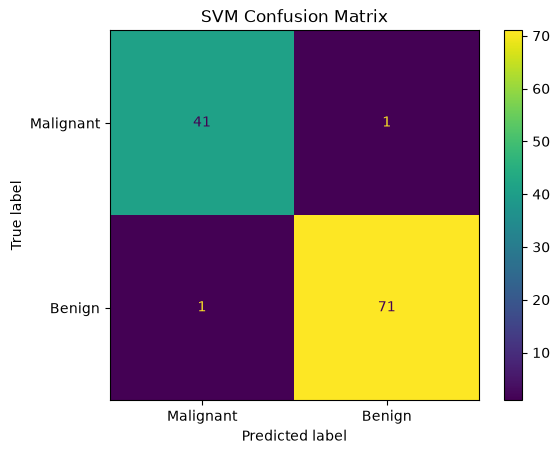

In [12]:

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
).plot()
plt.title("SVM Confusion Matrix")
plt.show()


## 10. ROC Curve

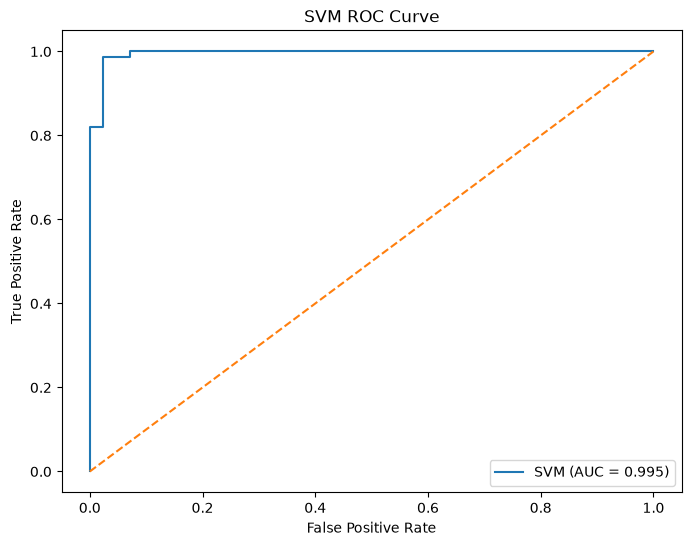

In [13]:

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()


## 11. Hyperparameter Tuning with GridSearchCV

In [14]:

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001],
    "kernel": ["rbf", "linear"]
}

grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid.best_params_)
print("\nBest Cross-Validation ROC-AUC:")
print(grid.best_score_)


Best Parameters:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Best Cross-Validation ROC-AUC:
0.9953560371517028


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 12. Evaluate the Tuned SVM

In [15]:

best_svm = grid.best_estimator_

y_pred_tuned = best_svm.predict(X_test_scaled)
y_prob_tuned = best_svm.predict_proba(X_test_scaled)[:, 1]

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

print("Tuned SVM Results")
print("-----------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)
print("ROC-AUC  :", tuned_auc)


Tuned SVM Results
-----------------
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112
ROC-AUC  : 0.9976851851851851


## 13. Conclusion

SVM was used to classify breast cancer observations into malignant and benign classes. The data were split into training and testing sets, standardized because SVM is sensitive to feature scale, and then classified using an RBF-kernel SVM. GridSearchCV was used to search for better hyperparameters, and the final model was evaluated using classification metrics and ROC-AUC.